Exported: fex_method.svg, fex_method.png


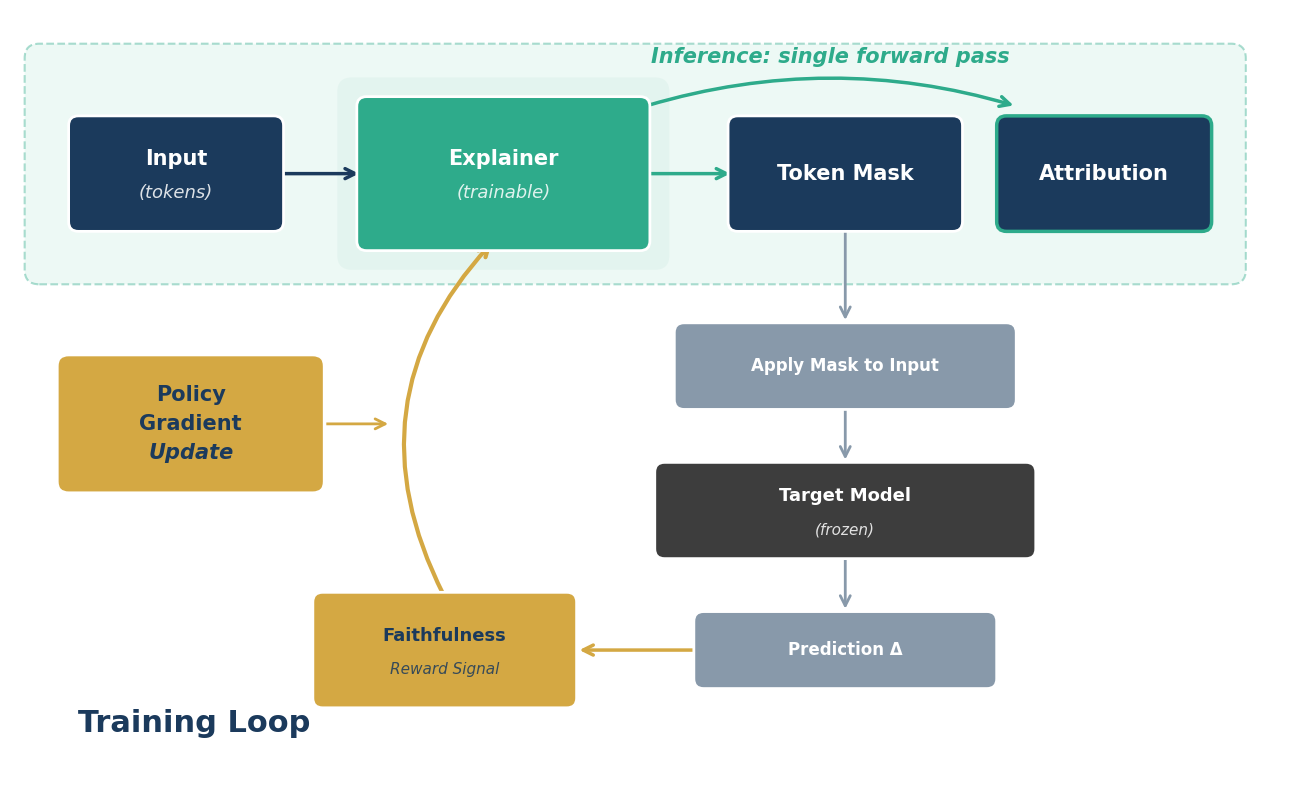

In [7]:
"""
FEX Method Architecture v2 — Revised
"""

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
import os

saving_path = os.path.join(os.getcwd(), "saved")

# COLOR PALETTE
BG_COLOR = '#E8ECF1'
NAVY     = '#1B3A5C'
TEAL     = '#2EAB8B'
GOLD     = '#D4A843'
RED      = '#C74B4B'
WHITE    = '#FFFFFF'
GRAY     = '#8899AA'
DARK_GRAY = '#3D3D3D'
LIGHT_TEAL = '#D4F0E7'

fig, ax = plt.subplots(1, 1, figsize=(13, 8))
fig.patch.set_facecolor('none')
ax.set_facecolor('none')
ax.set_xlim(0, 13)
ax.set_ylim(0, 8)
ax.axis('off')

def draw_box(x, y, w, h, label, facecolor, bordercolor, fontsize=12,
             fontcolor='white', borderwidth=2.0, sublabel=None, sublabel_color=None):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                          facecolor=facecolor, edgecolor=bordercolor,
                          linewidth=borderwidth, zorder=5)
    ax.add_patch(box)
    if sublabel:
        ax.text(x + w/2, y + h/2 + 0.15, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=fontcolor, zorder=6)
        sc = sublabel_color if sublabel_color else fontcolor
        ax.text(x + w/2, y + h/2 - 0.2, sublabel, ha='center', va='center',
                fontsize=fontsize - 2, color=sc, alpha=0.85, zorder=6, style='italic')
    else:
        ax.text(x + w/2, y + h/2, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=fontcolor, zorder=6)

def draw_arrow(x1, y1, x2, y2, color=GRAY, lw=2.0, style='->', curved=False, rad=0.0):
    if curved:
        arrow = FancyArrowPatch((x1, y1), (x2, y2),
                                 arrowstyle=style, mutation_scale=18,
                                 color=color, linewidth=lw, zorder=4,
                                 connectionstyle=f'arc3,rad={rad}')
    else:
        arrow = FancyArrowPatch((x1, y1), (x2, y2),
                                 arrowstyle=style, mutation_scale=18,
                                 color=color, linewidth=lw, zorder=4)
    ax.add_patch(arrow)

# ══════════════════════════════════════════════
# TOP ROW: Inference path
# ══════════════════════════════════════════════

# Inference highlight background
inf_bg = FancyBboxPatch((0.3, 5.3), 12.2, 2.2, boxstyle="round,pad=0.15",
                          facecolor=LIGHT_TEAL, edgecolor=TEAL,
                          linewidth=1.5, linestyle='--', alpha=0.4, zorder=1)
ax.add_patch(inf_bg)

# Input
draw_box(0.7, 5.8, 2.0, 1.0, 'Input', NAVY, WHITE, fontsize=15,
         sublabel='(tokens)')

# Arrow Input → Explainer
draw_arrow(2.75, 6.3, 3.6, 6.3, NAVY, lw=2.5)

# Explainer Network (key component)
draw_box(3.65, 5.6, 2.8, 1.4, 'Explainer', TEAL, WHITE, fontsize=15,
         sublabel='(trainable)', sublabel_color=WHITE)

# Teal glow
glow = FancyBboxPatch((3.5, 5.45), 3.1, 1.7, boxstyle="round,pad=0.15",
                        facecolor=TEAL, edgecolor='none',
                        alpha=0.08, zorder=0)
ax.add_patch(glow)

# Arrow Explainer → Token Mask
draw_arrow(6.5, 6.3, 7.4, 6.3, TEAL, lw=2.5)

# Token Mask (no sublabel)
draw_box(7.45, 5.8, 2.2, 1.0, 'Token Mask', NAVY, WHITE, fontsize=15)

# Arrow Explainer → Attribution (direct, curved over Token Mask)
draw_arrow(6.5, 7.0, 10.3, 7.0, TEAL, lw=2.5, curved=True, rad=-0.15)

# "Inference: single forward pass" label above the curved arrow
ax.text(8.4, 7.45, 'Inference: single forward pass', fontsize=15,
        color=TEAL, fontweight='bold', style='italic', ha='center')

# Attribution
draw_box(10.2, 5.8, 2.0, 1.0, 'Attribution', NAVY, TEAL, fontsize=15,
         borderwidth=2.5)

# ══════════════════════════════════════════════
# TRAINING LOOP
# ══════════════════════════════════════════════

# Arrow: Token Mask down to "Apply Mask"
draw_arrow(8.55, 5.8, 8.55, 4.75, GRAY, lw=2.0)

# Apply Mask to Input
draw_box(6.9, 3.95, 3.3, 0.7, 'Apply Mask to Input', GRAY, WHITE,
         fontsize=12, fontcolor=WHITE)

# Arrow down
draw_arrow(8.55, 3.95, 8.55, 3.3, GRAY, lw=2.0)

# Target Model (frozen)
draw_box(6.7, 2.4, 3.7, 0.8, 'Target Model', DARK_GRAY, WHITE,
         fontsize=13, sublabel='(frozen)')

# Arrow down
draw_arrow(8.55, 2.4, 8.55, 1.75, GRAY, lw=2.0)

# Prediction change
draw_box(7.1, 1.05, 2.9, 0.6, 'Prediction \u0394', GRAY, WHITE,
         fontsize=12, fontcolor=WHITE)

# Arrow left from Prediction to Reward
draw_arrow(7.1, 1.35, 5.8, 1.35, GOLD, lw=2.5)

# Faithfulness Reward
draw_box(3.2, 0.85, 2.5, 1.0, 'Faithfulness', GOLD, WHITE, fontsize=13,
         fontcolor=NAVY, sublabel='Reward Signal', sublabel_color=NAVY)

# Arrow up from Reward back to Explainer (curved)
draw_arrow(4.45, 1.9, 4.95, 5.6, GOLD, lw=3.0, curved=True, rad=-0.35)

# Policy Gradient Update — HIGHLIGHTED
# Box center: x=1.85, y=2.8
pg_box = FancyBboxPatch((0.6, 3.1), 2.5, 1.2, boxstyle="round,pad=0.12",
                          facecolor=GOLD, edgecolor=WHITE,
                          linewidth=2.5, zorder=5)
ax.add_patch(pg_box)
ax.text(1.85, 4.0, 'Policy', ha='center', va='center',
        fontsize=15, fontweight='bold', color=NAVY, zorder=6)
ax.text(1.85, 3.7, 'Gradient', ha='center', va='center',
        fontsize=15, fontweight='bold', color=NAVY, zorder=6)
ax.text(1.85, 3.4, 'Update', ha='center', va='center',
        fontsize=15, fontweight='bold', color=NAVY, zorder=6,
        style='italic')

# Arrow from PG box to the curved gold arrow
draw_arrow(3.15, 3.7, 3.9, 3.7, GOLD, lw=2.0)

# ══════════════════════════════════════════════
# TRAINING LOOP LABEL — plain text, bottom left
# ══════════════════════════════════════════════
ax.text(0.7, 0.5, 'Training Loop', fontsize=22, color=NAVY,
        fontweight='bold', zorder=10)

plt.tight_layout()
plt.savefig(os.path.join(saving_path, 'fex_method.svg'), format='svg',
            bbox_inches='tight', transparent=True)
plt.savefig(os.path.join(saving_path, 'fex_method.png'), dpi=300,
            bbox_inches='tight', transparent=True)
print("Exported: fex_method.svg, fex_method.png")
